<a href="https://colab.research.google.com/github/EvelynNguyenPortfolio/CS-349/blob/main/HWK2/data_prep_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import sys
assert sys.version_info >= (3, 10)
from packaging.version import Version
import sklearn
assert Version(sklearn.__version__) >= Version("1.6.1")

In [18]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

import kagglehub

#Importing data
path = kagglehub.dataset_download("dnkumars/cybersecurity-intrusion-detection-dataset")

print("Path to dataset files:", path)

def load_cs_data():
    path = kagglehub.dataset_download(
        "dnkumars/cybersecurity-intrusion-detection-dataset"
    )

    csv_file = list(Path(path).glob("*.csv"))[0]

    return pd.read_csv(csv_file)

cs = load_cs_data()

Using Colab cache for faster access to the 'cybersecurity-intrusion-detection-dataset' dataset.
Path to dataset files: /kaggle/input/cybersecurity-intrusion-detection-dataset
Using Colab cache for faster access to the 'cybersecurity-intrusion-detection-dataset' dataset.


In [19]:
cs.head()

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [20]:
cs.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB


In [21]:
cs.describe()

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942,0.447101
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034,0.497220
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000


In [22]:
cs.drop(columns=["session_id"])

,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0
...,...,...,...,...,...,...,...,...,...,...
9532,194,ICMP,3,226.049889,AES,0.517737,3,Chrome,0,1
9533,380,TCP,3,182.848475,NaN,0.408485,0,Chrome,0,0
9534,664,TCP,5,35.170248,AES,0.359200,1,Firefox,0,0
9535,406,TCP,4,86.664703,AES,0.537417,1,Chrome,1,0


In [23]:
#Finding missing values
cs.isnull().sum()

,0
session_id,0
network_packet_size,0
protocol_type,0
login_attempts,0
session_duration,0
encryption_used,1966
ip_reputation_score,0
failed_logins,0
browser_type,0
unusual_time_access,0


In [24]:
#Dropping missing values
cs_clean = cs.copy()
cs_clean.dropna(subset=["encryption_used"], inplace=True)
cs_clean.isnull().sum()

,0
session_id,0
network_packet_size,0
protocol_type,0
login_attempts,0
session_duration,0
encryption_used,0
ip_reputation_score,0
failed_logins,0
browser_type,0
unusual_time_access,0


In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

#Taking out target value
x_var = cs.drop('attack_detected', axis = 1)
y_var = cs['attack_detected']

#Separation of numerical and categorical data
num_var = x_var.select_dtypes(include=[np.int64, np.float64]).columns
cat_var = x_var.select_dtypes(include=['object']).columns


num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

#Used SimpleImputer(strategy="constant", fill_value = "none") because having no encryption seems like it contributes to target value and the rows should not be dropped
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="constant", fill_value = "none")),
    ('encoder', OneHotEncoder(sparse_output = False)),
])

cs_prep = fullpipeline = ColumnTransformer([
    ("num", num_pipeline, num_var),
    ("cat", cat_pipeline, cat_var),
])

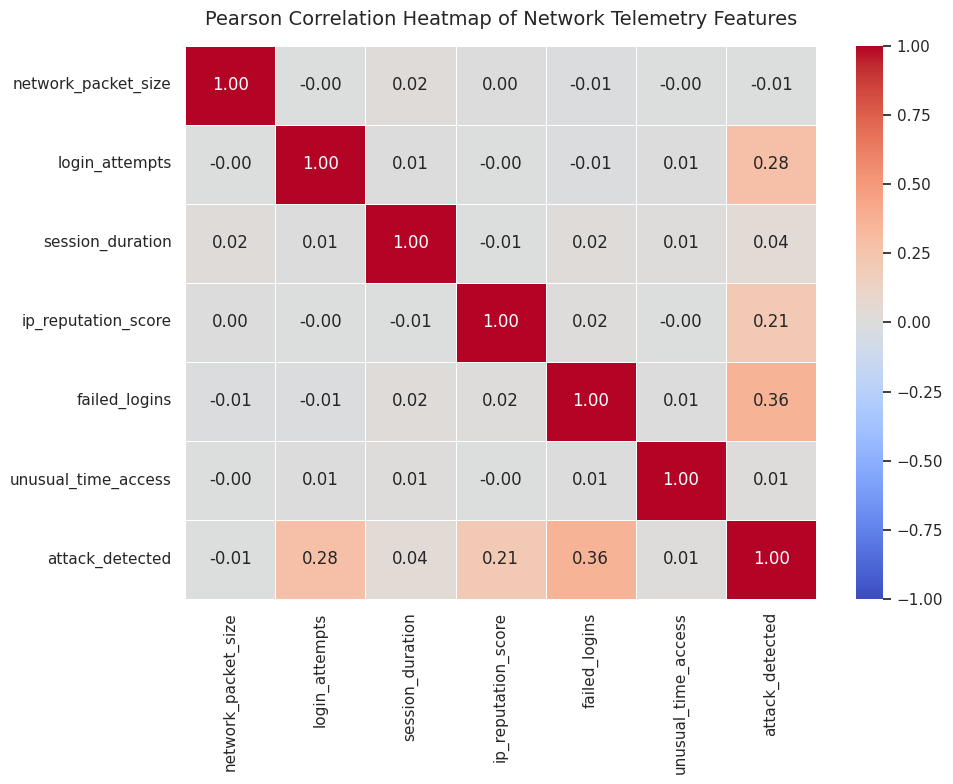

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

#Pearson Correlation Matrix
corr_matrix = cs[cs.select_dtypes(include=[np.int64, np.float64]).columns].corr(method='pearson')

#Seaborn HeatMap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title('Pearson Correlation Heatmap of Network Telemetry Features', fontsize=14, pad=15)
plt.tight_layout()
plt.show()



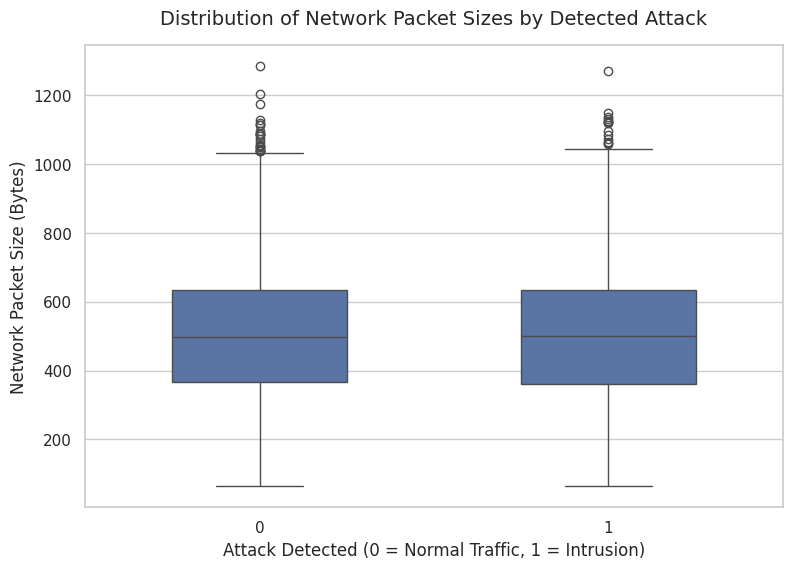

In [27]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

#Boxplot showing distribution relationship between attack detected and network_packet_size
sns.boxplot(
    data=cs,
    x='attack_detected',
    y='network_packet_size',
    width=0.5
)

plt.title('Distribution of Network Packet Sizes by Detected Attack', fontsize=14, pad=15)
plt.xlabel('Attack Detected (0 = Normal Traffic, 1 = Intrusion)', fontsize=12)
plt.ylabel('Network Packet Size (Bytes)', fontsize=12)

plt.show()

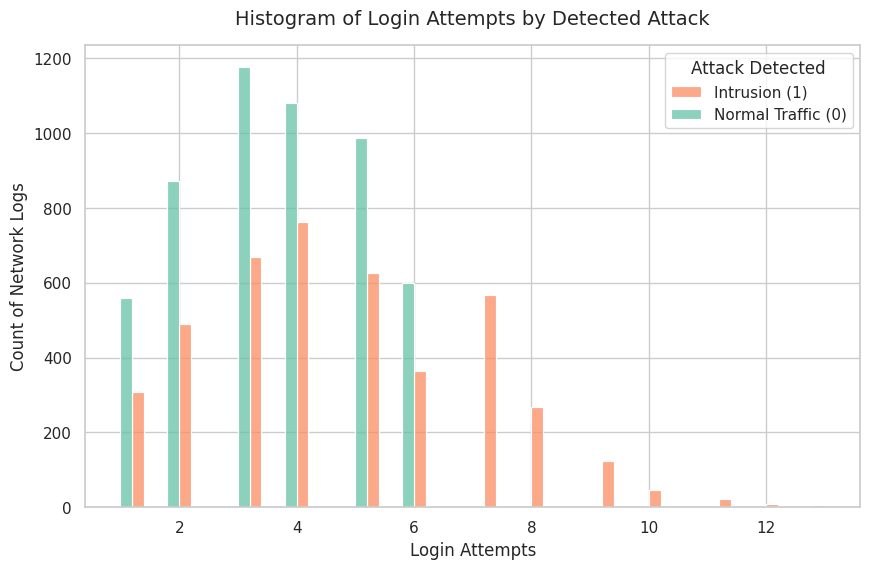

In [28]:
plt.figure(figsize=(10, 6))

#Histogram to show Login Attempts by Detected Attack
sns.histplot(
    data=cs,
    x='login_attempts',
    hue='attack_detected',
    multiple='dodge',
    palette='Set2',
    bins=30,
    kde=False
)

plt.title('Histogram of Login Attempts by Detected Attack', fontsize=14, pad=15)
plt.xlabel('Login Attempts', fontsize=12)
plt.ylabel('Count of Network Logs', fontsize=12)
plt.legend(title='Attack Detected', labels=['Intrusion (1)', 'Normal Traffic (0)'])

plt.show()

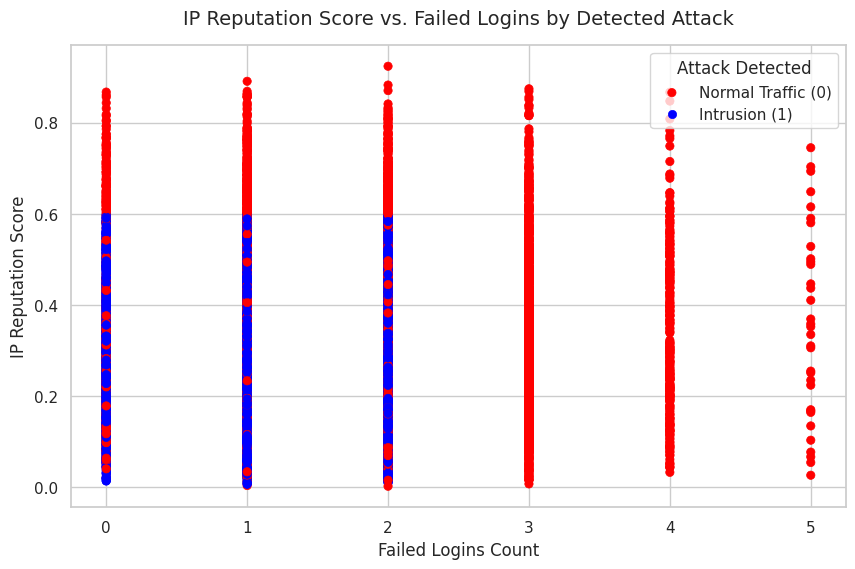

In [29]:
plt.figure(figsize=(10, 6))

#Scatterplot to show IP Reputation Score vs. Failed Logins by Detected Attack
sns.scatterplot(
    data=cs,
    x='failed_logins',
    y='ip_reputation_score',
    hue='attack_detected',
    palette={0: 'blue', 1: 'red'},
    edgecolor=None
)

plt.title('IP Reputation Score vs. Failed Logins by Detected Attack', fontsize=14, pad=15)
plt.xlabel('Failed Logins Count', fontsize=12)
plt.ylabel('IP Reputation Score', fontsize=12)
plt.legend(title='Attack Detected', labels=['Normal Traffic (0)', 'Intrusion (1)'])


plt.show()

# Homework 2 Analysis
1. What challenges did you encounter when loading and inspecting a raw external dataset from Kaggle compared to pre-packaged datasets?

I encountered having missing or NaN values for one of my features (encryption_used). I had to clean up these missing values by either getting rid of the rows that held them or by replacing NaN with the constant 'none'.

2. How did you determine which columns required missing value imputation versus other data cleaning methods, and what strategy did you choose?

I used cs.isnull().sum() to find the sum of missing values for each column. For the initial task of cleaning up the missing values of encryption_used, I simply rid of the rows that held the missing values. However for the task to build a Scikit-Learn ColumnTransformer and Pipeline, I decided to use the strategy 'constant' and replacing NaN with the constant value 'none'. The reason is first because the column is categorical and I cannot use the strategy 'median'. The second reason is because having no encryption seems like it contributes to and has a relationship with the target value. As a result, I believe the rows should not be dropped

3. Explain how the Scikit-Learn ColumnTransformer and Pipeline streamline the data preparation process and prevent data leakage across preprocessing steps.

The Scikit-Learn ColumnTransformer and Pipeline streamline the data preparation by allowing you to apply certain transformations on specific columns all at once while chaining the transformatnio steps sequentially.

4. Based on your correlation matrix and heatmap, which features show the strongest relationships with the target variable (attack_detected), and what operational insights do these relationships reveal?

The number of logins, failed attempts and the ip reputation score had the strongest relationshps with the target variable. This reveals that a high amount of failed login attemtps along with getting pinged by an ip address with a bad trustworthiness rating can be indicators of an attack and should be blocked. An AI can be trained to look for these indicators and proactively stop suspicious login activities.